## Comparing F1 score of all models for each batch_size

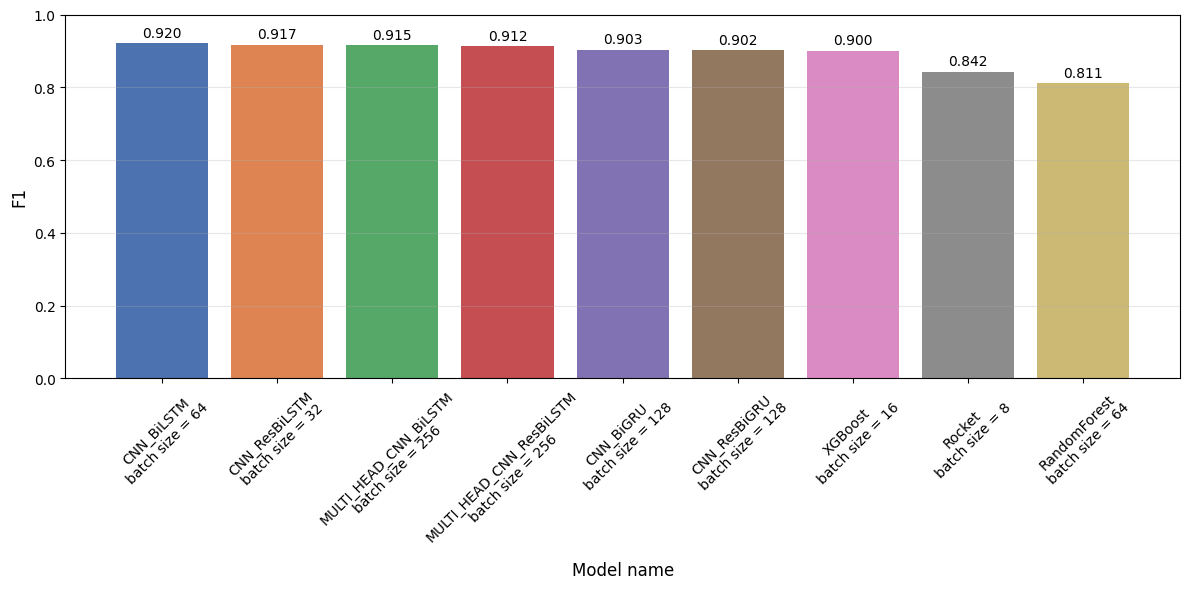

In [5]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Find all batch size result directories
batch_sizes = [8, 16, 32, 64, 128, 256]
all_results = []

for bs in batch_sizes:
    dir_name = f"model_comparison_results_batch_size_{bs}"
    results_path = os.path.join(dir_name, "results.json")
    if os.path.exists(results_path):
        with open(results_path, 'r') as f:
            data = json.load(f)
            for model_name, info in data.items():
                if 'metrics' in info and 'f1_score' in info['metrics']:
                    all_results.append({
                        'Batch_Size': bs,
                        'Model': model_name,
                        'F1_Score': info['metrics']['f1_score']
                    })

df = pd.DataFrame(all_results)

# Get the best result for each model
best_models = df.loc[df.groupby('Model')['F1_Score'].idxmax()].copy()
best_models = best_models.sort_values('F1_Score', ascending=False)
best_models['Model_Label'] = best_models['Model'] + '\nbatch size = ' + best_models['Batch_Size'].astype(str)

# Plotting: One single plot
plt.figure(figsize=(12, 6))

models_labels = best_models['Model_Label'].tolist()
values = best_models['F1_Score'].tolist()

palette = sns.color_palette('deep', len(models_labels))

bars = plt.bar(models_labels, values, color=palette)
# plt.title('Labākais F1 rezultāts katram modelim', fontsize=14)
plt.ylim(0, 1.0)
plt.grid(axis='y', alpha=0.3)
plt.xlabel('Model name', fontsize=12)
plt.ylabel('F1', fontsize=12)
plt.xticks(rotation=45, ha='center')

for bar, value in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width() / 2, min(value + 0.01, 0.99), f'{value:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()

# Save the plot
os.makedirs('Models', exist_ok=True)
plt.savefig('Models/best_models_comparison.png', dpi=180, bbox_inches='tight')

plt.show()

## Confussion matrix of best performing model based on F1 score

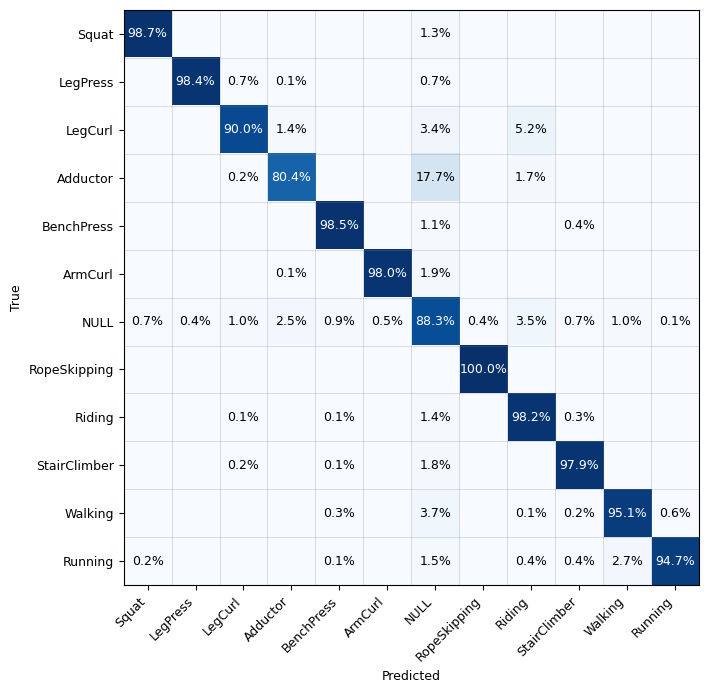

In [6]:
import json
import numpy as np
import matplotlib.pyplot as plt





plt.rcParams.update({'font.size': 9})

# Load the CNN_ResBiLSTM confusion matrix from the studies folder
results_path = "studies/optuna_optimize_CNN_ResBiLSTM/results.json"

with open(results_path, 'r') as f:
    data = json.load(f)

model_name = "CNN_ResBiLSTM"
model_result = data.get(model_name)

if model_result and 'confusion_matrix' in model_result:
    best_cm = np.array(model_result['confusion_matrix'], dtype=np.float64)
    metrics = model_result.get('metrics', {})
    best_accuracy = metrics.get('accuracy', 0)
    best_f1 = metrics.get('f1_score', 0)

    # Reorder the matrix to match the requested activity order.
    id_to_activity = {
        0: 'Adductor', 1: 'ArmCurl', 2: 'BenchPress', 3: 'LegCurl', 
        4: 'LegPress', 5: 'NULL', 6: 'Riding', 7: 'RopeSkipping', 
        8: 'Running', 9: 'Squat', 10: 'StairClimber', 11: 'Walking'
    }
    desired_order = [
        'Squat', 'LegPress', 'LegCurl', 'Adductor', 'BenchPress', 'ArmCurl',
        'NULL', 'RopeSkipping', 'Riding', 'StairClimber', 'Walking', 'Running'
    ]
    activity_to_id = {activity: activity_id for activity_id, activity in id_to_activity.items()}
    order_indices = [activity_to_id[name] for name in desired_order]
    best_cm = best_cm[np.ix_(order_indices, order_indices)]
    class_names = desired_order

    num_classes = len(class_names)
    
    # Calculate density for rows
    row_sums = best_cm.sum(axis=1, keepdims=True)
    cm = np.divide(best_cm, row_sums, out=np.zeros_like(best_cm), where=row_sums != 0)

    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(cm, cmap="Blues", vmin=0.0, vmax=1.0)

    # ax.set_title(f"{model_name} (Batch Size = 32, LSTM layers = 4)\n(Accuracy: {best_accuracy:.2%}, F1: {best_f1:.4f})", fontsize=12)
    ax.set_xlabel("Predicted", fontsize=9)
    ax.set_ylabel("True", fontsize=9)

    ax.set_xticks(np.arange(num_classes))
    ax.set_yticks(np.arange(num_classes))
    ax.set_xticklabels(class_names, rotation=45, ha="right", fontsize=9)
    ax.set_yticklabels(class_names, fontsize=9)

    # Add a cell grid
    ax.set_xticks(np.arange(-0.5, num_classes, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, num_classes, 1), minor=True)
    ax.grid(which="minor", color="gray", linestyle="-", linewidth=0.5, alpha=0.35)
    ax.tick_params(which="minor", bottom=False, left=False)

    # Show non-zero densities as percentages
    if num_classes <= 20:
        for i in range(num_classes):
            for j in range(num_classes):
                value = cm[i, j]
                if value > 0:
                    text_color = "white" if value >= 0.6 else "black"
                    ax.text(j, i, f"{value:.1%}", ha="center", va="center", color=text_color, fontsize=9)

    plt.tight_layout()
    plt.savefig('Models/CNN_ResBiLSTM_confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("Confusion matrix data not found in studies/optuna_optimize_CNN_ResBiLSTM/results.json.")

In [4]:
import json
import pandas as pd

# Load results for batch size 64
results_path = "model_comparison_results_batch_size_64/results.json"
metrics_data = []

# Parameters from the example table
parameters_map = {
    'CNN_BiLSTM': 295692,
    'MULTI_HEAD_CNN_ResBiLSTM': 601292,
    'XGBoost': 300,
    'MULTI_HEAD_CNN_BiLSTM': 608908,
    'CNN_BiGRU': 244492,
    'CNN_ResBiLSTM': 230668,
    'CNN_ResBiGRU': 195852,
    'Rocket': 1000,
    'RandomForest': 300
}

with open(results_path, 'r') as f:
    data = json.load(f)
    for model_name, info in data.items():
        if 'metrics' in info:
            m = info['metrics']
            metrics_data.append({
                'Model': model_name.replace('_', '\\_'),
                'Accuracy': m.get('accuracy', 0),
                'Precision': m.get('precision', 0),
                'Recall': m.get('recall', 0),
                'F1': m.get('f1_score', 0),
                'Parameters': parameters_map.get(model_name, 0)
            })

df_metrics = pd.DataFrame(metrics_data)
# Sort by F1 descending
df_metrics = df_metrics.sort_values(by='F1', ascending=False)

# Formatting functions
formatters = {
    'Accuracy': lambda x: f"{x:.4f}",
    'Precision': lambda x: f"{x:.4f}",
    'Recall': lambda x: f"{x:.4f}",
    'F1': lambda x: f"{x:.4f}",
    'Parameters': lambda x: f"{x}"
}

# Generate latex
latex_table = df_metrics.to_latex(
    index=False,
    formatters=formatters,
    column_format="lrrrrr",
    escape=False # Because we already escaped underscores manually
)

# Wrap in the requested table structure
latex_output = f"""\\begin{{table*}}[t]
\\centering
\\caption{{Model comparison metrics sorted by F1 for batch size 64.}}
\\label{{tab:model_comparison_batch_64}}
\\setlength{{\\tabcolsep}}{{5pt}}
{latex_table.strip()}
\\end{{table*}}
"""

print(latex_output)

\begin{table*}[t]
\centering
\caption{Model comparison metrics sorted by F1 for batch size 64.}
\label{tab:model_comparison_batch_64}
\setlength{\tabcolsep}{5pt}
\begin{tabular}{lrrrrr}
\toprule
Model & Accuracy & Precision & Recall & F1 & Parameters \\
\midrule
CNN\_BiLSTM & 0.9309 & 0.8969 & 0.9469 & 0.9203 & 295692 \\
CNN\_ResBiLSTM & 0.9138 & 0.8627 & 0.9524 & 0.9035 & 230668 \\
CNN\_BiGRU & 0.9100 & 0.8635 & 0.9535 & 0.9022 & 244492 \\
MULTI\_HEAD\_CNN\_BiLSTM & 0.9090 & 0.8757 & 0.9404 & 0.9020 & 608908 \\
MULTI\_HEAD\_CNN\_ResBiLSTM & 0.9146 & 0.8601 & 0.9519 & 0.9013 & 601292 \\
XGBoost & 0.9196 & 0.8975 & 0.9003 & 0.8986 & 300 \\
CNN\_ResBiGRU & 0.9072 & 0.8478 & 0.9491 & 0.8933 & 195852 \\
Rocket & 0.8886 & 0.9344 & 0.7869 & 0.8417 & 1000 \\
RandomForest & 0.7904 & 0.8038 & 0.8608 & 0.8110 & 300 \\
\bottomrule
\end{tabular}
\end{table*}

